# Climate-GEA SNP vs non-SNP — 3-model grid, INFLATION-CORRECTED (fresh cohort)

Same layout as `grid_3model_snp_vs_nonsnp` but with the settled corrections:
**binomial row = quasi-binomial + K16** (`pval_quasi`; the fix for the plain
binomial's GIF~17 over-precision → GIF~3.2), **kendall row = raw** (every honest
correction flattens its pseudoreplicated peaks; kept as the phase-1 reference),
**lfmm row = as-is** (already latent-factor calibrated). gen9, bio1, clq0.9
(blocks_recompute) haploblocks, WZA deg7-cap2000. CAM5/AT2G27030 (3'-end peak,
block Chr2_6779) circled.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

GNP     = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/gea_newpanel/results"
CLASSES = ["snp", "nonsnp"]
MODELS  = ["binomial", "kendall", "lfmm"]          # columns (binomial = quasi-binomial)
COLTITLE = {"binomial": "quasi-binomial+K16 (corrected)",
            "kendall": "kendall (raw ref)", "lfmm": "lfmm (calibrated)"}
# per-model raw + WZA file stems (binomial row uses the quasi-binomial files)
RAWSTEM = {"binomial": "quasibinom", "kendall": "kendall", "lfmm": "lfmm"}
WZASTEM = {"binomial": "quasibinom", "kendall": "kendall", "lfmm": "lfmm"}
CAM5_BLOCK = "Chr2_6779"
CHROMS  = [f"Chr{i}" for i in range(1, 6)]
Q_FLOOR = 1e-16; MAF_FILTER = 0.05

def load_wza(model, cls):
    w = pd.read_csv(f"{GNP}/wza_{WZASTEM[model]}_{cls}_clq09.csv").rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna() & w["chrom"].astype(str).isin(CHROMS)].copy()
    w["chrom"] = w["chrom"].astype(str); w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=Q_FLOOR))
    return w

def load_raw(model, cls):
    d = pd.read_csv(f"{GNP}/{RAWSTEM[model]}_{cls}_gen9_bio1_clq09.csv", usecols=["chrom", "pos", "MAF", "pval"])
    d = d[(d.MAF >= MAF_FILTER) & d.chrom.astype(str).isin(CHROMS)].copy()
    d["chrom"] = d["chrom"].astype(str); d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR))
    return d

allpos = pd.concat([load_raw("kendall", c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6; offset, off = {}, 0.0
for c in CHROMS: offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

def bh_sig_blocks(model, cls, q=0.05):
    w = load_wza(model, cls).copy(); p = w["Z_pVal"].to_numpy()
    order = np.argsort(p); m = len(p); qv = np.empty(m)
    qv[order] = np.minimum.accumulate((p[order] * m / (np.arange(m) + 1))[::-1])[::-1]
    return set(w.loc[qv < q, "block"])

print("WZA grid:", {(m, c): len(load_wza(m, c)) for m in MODELS for c in CLASSES})

WZA grid: {('binomial', 'snp'): 81708, ('binomial', 'nonsnp'): 68771, ('kendall', 'snp'): 81697, ('kendall', 'nonsnp'): 68780, ('lfmm', 'snp'): 81699, ('lfmm', 'nonsnp'): 68780}


## (1) Raw per-record results (pre-WZA)

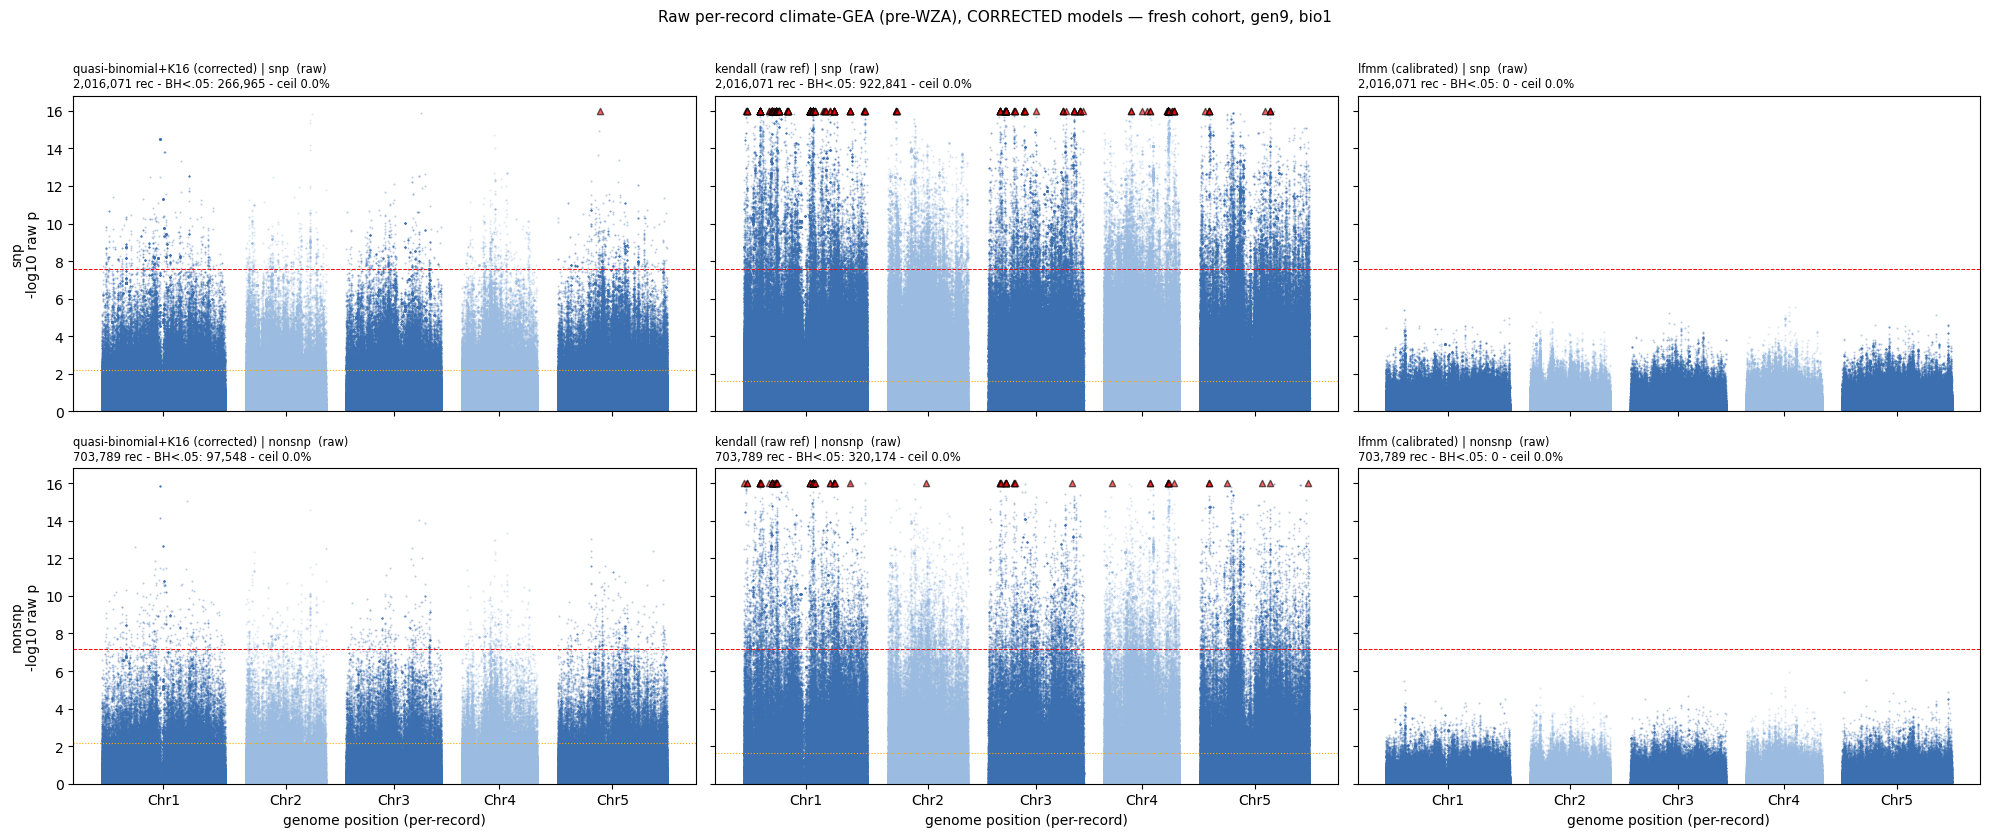

In [2]:
RAW_YMAX = -np.log10(Q_FLOOR)
fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(20, 8.5), sharex=True, sharey=True)
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]; d = load_raw(model, cls).copy(); d["x"] = d["pos"] + d["chrom"].map(offset)
        n = len(d); ofs = d["pval"] < Q_FLOOR
        for c in CHROMS:
            m = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][m], d["mlogp"][m].clip(upper=RAW_YMAX), s=2, c=chrom_col[c], alpha=.35, linewidths=0, rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=20, color="red", edgecolor="k", zorder=6, alpha=.6)
        ax.axhline(-np.log10(0.05 / n), color="red", lw=0.7, ls="--")
        nbh, crit = bh_count_crit(d["pval"].to_numpy())
        if nbh: ax.axhline(-np.log10(crit), color="orange", lw=0.8, ls=":")
        ax.set_title(f"{COLTITLE[model]} | {cls}  (raw)\n{n:,} rec - BH<.05: {nbh:,} - ceil {ofs.mean():.1%}", fontsize=8.3, loc="left")
        if cc == 0: ax.set_ylabel(f"{cls}\n-log10 raw p", fontsize=10)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS); ax.set_xlabel("genome position (per-record)")
fig.suptitle("Raw per-record climate-GEA (pre-WZA), CORRECTED models — fresh cohort, gen9, bio1", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_raw.png", dpi=130, bbox_inches="tight"); plt.show()

## (2) WZA-aggregated Manhattan grid (deg7-cap2000)

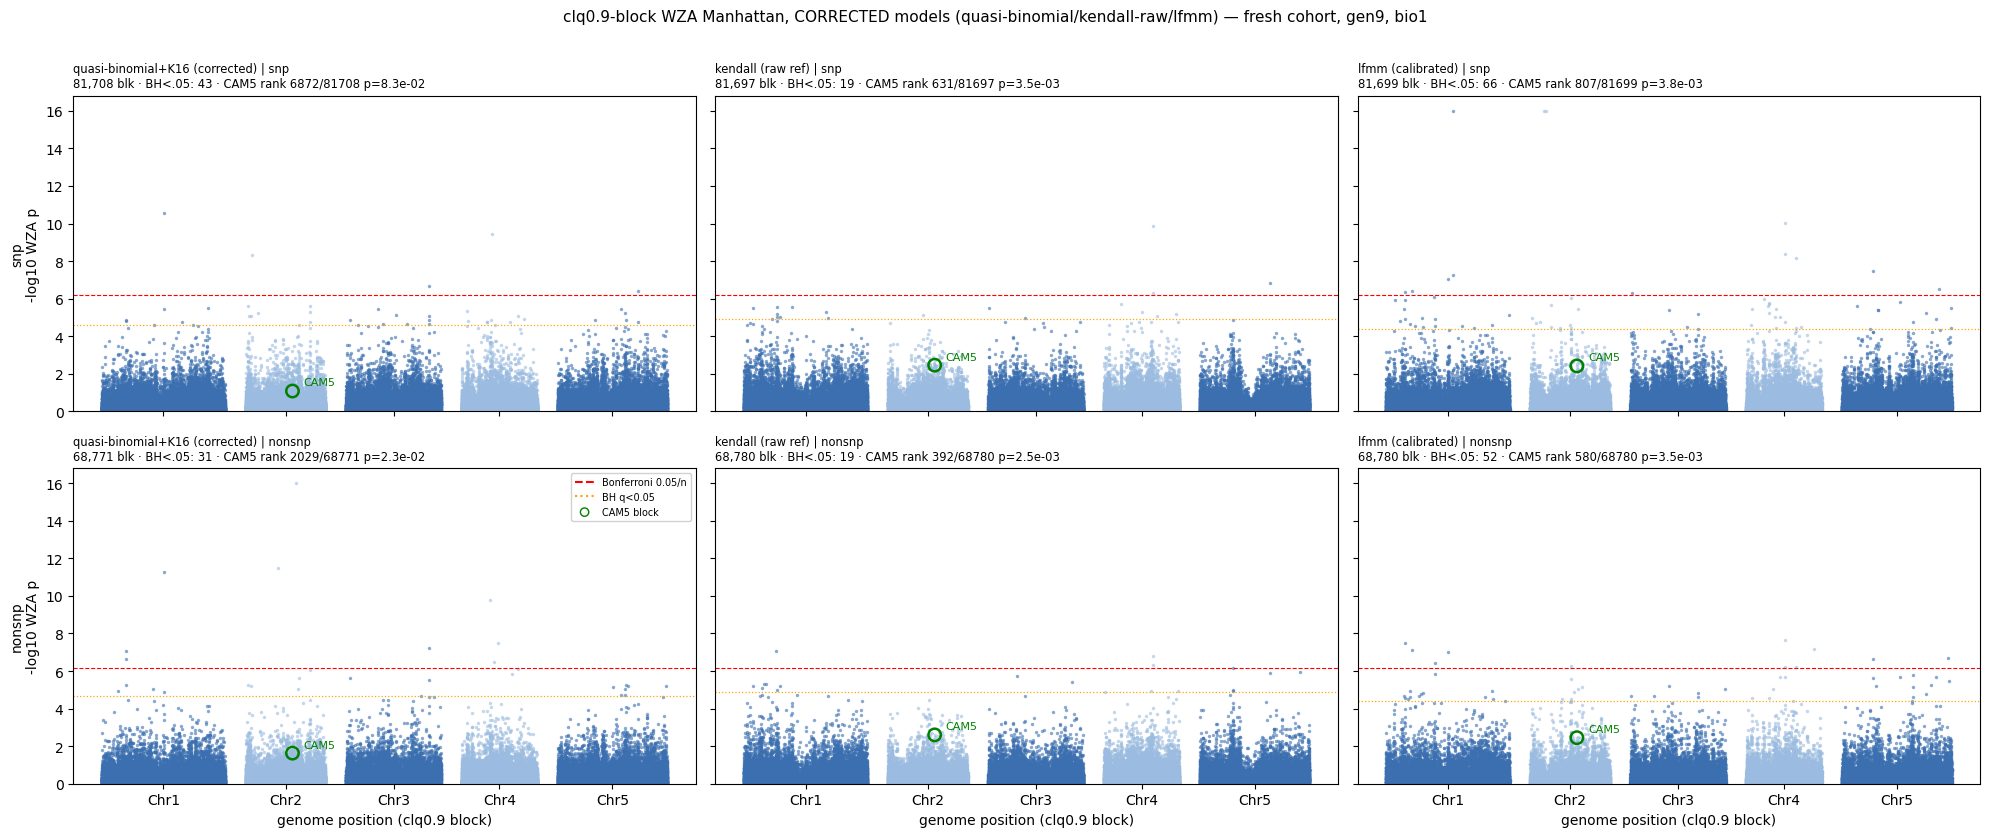

,model,cls,n_blocks,n_bh,cam5_present
0,binomial,snp,81708,43,True
1,kendall,snp,81697,19,True
2,lfmm,snp,81699,66,True
3,binomial,nonsnp,68771,31,True
4,kendall,nonsnp,68780,19,True
5,lfmm,nonsnp,68780,52,True


In [3]:
YMAX = -np.log10(Q_FLOOR)
fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(20, 8.5), sharex=True, sharey=True)
grid_rows = []
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]; w = load_wza(model, cls).copy(); w["x"] = w["pos"] + w["chrom"].map(offset)
        n = len(w); ofs = w["mlogp"] > YMAX
        for c in CHROMS:
            m = (w["chrom"] == c) & ~ofs
            ax.scatter(w["x"][m], w["mlogp"][m].clip(upper=YMAX), s=6, c=chrom_col[c], alpha=.6, linewidths=0, rasterized=True)
        if ofs.any():
            ax.scatter(w["x"][ofs], np.full(int(ofs.sum()), YMAX), marker="^", s=35, color="red", edgecolor="k", zorder=6)
        ax.axhline(-np.log10(0.05 / n), color="red", lw=0.8, ls="--")
        nbh, crit = bh_count_crit(w["Z_pVal"])
        if nbh: ax.axhline(-np.log10(crit), color="orange", lw=0.9, ls=":")
        ws = w.sort_values("Z_pVal").reset_index(drop=True); cam = ws[ws["block"] == CAM5_BLOCK]
        if len(cam):
            cb = cam.iloc[0]; rank = int(ws.index[ws["block"] == CAM5_BLOCK][0]) + 1; cy = min(cb["mlogp"], YMAX)
            ax.scatter(cb["x"], cy, s=80, facecolors="none", edgecolors="green", linewidths=1.8, zorder=7)
            ax.annotate("CAM5", (cb["x"], cy), color="green", fontsize=8, xytext=(8, 4), textcoords="offset points", zorder=8)
            camtxt = f" · CAM5 rank {rank}/{n} p={cb['Z_pVal']:.1e}"
        else:
            camtxt = " · CAM5 absent"
        ax.set_title(f"{COLTITLE[model]} | {cls}\n{n:,} blk · BH<.05: {nbh}{camtxt}", fontsize=8.3, loc="left")
        if cc == 0: ax.set_ylabel(f"{cls}\n-log10 WZA p", fontsize=10)
        ax.set_ylim(0, YMAX + 0.8)
        grid_rows.append(dict(model=model, cls=cls, n_blocks=n, n_bh=nbh, cam5_present=bool(len(cam))))
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS); ax.set_xlabel("genome position (clq0.9 block)")
axes[-1, 0].plot([], [], color="red", ls="--", label="Bonferroni 0.05/n")
axes[-1, 0].plot([], [], color="orange", ls=":", label="BH q<0.05")
axes[-1, 0].scatter([], [], facecolors="none", edgecolors="green", label="CAM5 block")
axes[-1, 0].legend(fontsize=7, loc="upper right", framealpha=0.9)
fig.suptitle("clq0.9-block WZA Manhattan, CORRECTED models (quasi-binomial/kendall-raw/lfmm) — fresh cohort, gen9, bio1", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_wza.png", dpi=130, bbox_inches="tight"); plt.show()
pd.DataFrame(grid_rows)

## Overlapping peaks (1): SNP vs non-SNP BH-significant blocks, per model

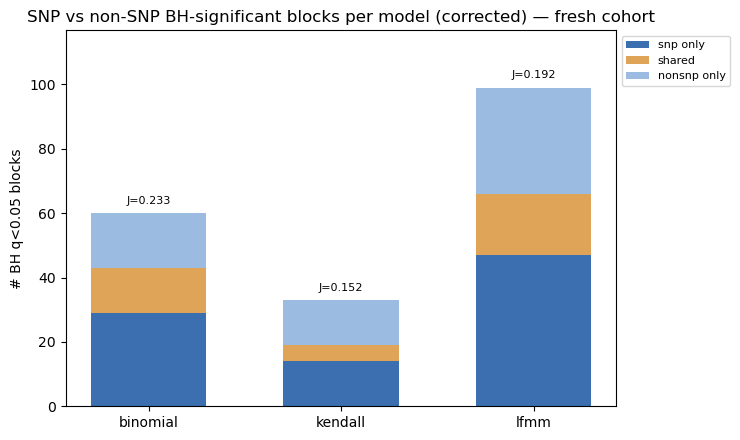

,model,n_snp_sig,n_nonsnp_sig,n_shared,jaccard
0,quasi-binomial+K16 (corrected),43,31,14,0.233
1,kendall (raw ref),19,19,5,0.152
2,lfmm (calibrated),66,52,19,0.192


In [4]:
overlap_rows = []
for model in MODELS:
    s = bh_sig_blocks(model, "snp"); ns = bh_sig_blocks(model, "nonsnp")
    shared = s & ns; union = s | ns
    overlap_rows.append(dict(model=COLTITLE[model], n_snp_sig=len(s), n_nonsnp_sig=len(ns),
        n_shared=len(shared), jaccard=round(len(shared)/len(union), 3) if union else np.nan))
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_overlap.csv", index=False)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(MODELS)); bw = 0.6
snp_only = overlap_df["n_snp_sig"] - overlap_df["n_shared"]
nonsnp_only = overlap_df["n_nonsnp_sig"] - overlap_df["n_shared"]; shared = overlap_df["n_shared"]
ax.bar(x, snp_only, bw, label="snp only", color="#3b6fb0")
ax.bar(x, shared, bw, bottom=snp_only, label="shared", color="#e0a458")
ax.bar(x, nonsnp_only, bw, bottom=snp_only + shared, label="nonsnp only", color="#9bbce0")
ax.set_xticks(x); ax.set_xticklabels([m for m in MODELS]); ax.set_ylabel("# BH q<0.05 blocks")
ax.set_title("SNP vs non-SNP BH-significant blocks per model (corrected) — fresh cohort")
tot = (overlap_df["n_snp_sig"] + overlap_df["n_nonsnp_sig"] - overlap_df["n_shared"]); ymax = max(tot.max(), 1)
ax.set_ylim(0, ymax * 1.18)
for i, row in overlap_df.iterrows(): ax.annotate(f"J={row.jaccard}", (i, tot[i] + ymax * 0.03), ha="center", fontsize=8)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0)); fig.tight_layout()
fig.savefig(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_snp_nonsnp_overlap.png", dpi=130, bbox_inches="tight"); plt.show()
overlap_df

## Overlapping peaks (2): cross-model agreement, per class

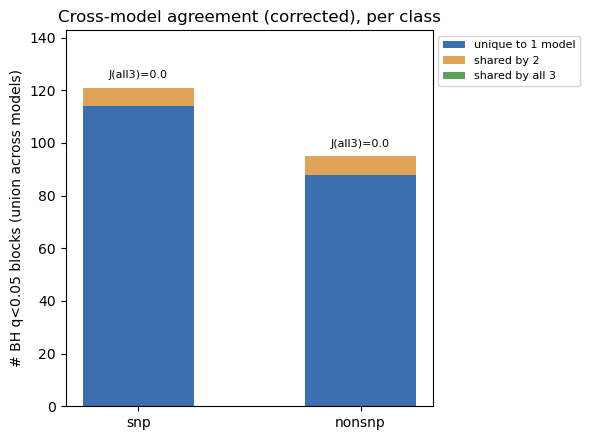

,cls,n_union,binomial_only,kendall_only,lfmm_only,binomial&kendall_only,binomial&lfmm_only,kendall&lfmm_only,all_3,jaccard_all3
0,snp,121,41,14,59,0,2,5,0,0.0
1,nonsnp,95,28,15,45,0,3,4,0,0.0


In [5]:
from itertools import combinations
rows = []
for cls in CLASSES:
    sets = {m: bh_sig_blocks(m, cls) for m in MODELS}
    union = set.union(*sets.values()) if sets else set()
    row = dict(cls=cls, n_union=len(union))
    for m in MODELS:
        others = set.union(*[sets[o] for o in MODELS if o != m]); row[f"{m}_only"] = len(sets[m] - others)
    for a, b in combinations(MODELS, 2):
        c_ = [o for o in MODELS if o not in (a, b)][0]; row[f"{a}&{b}_only"] = len((sets[a] & sets[b]) - sets[c_])
    all3 = set.intersection(*sets.values()); row["all_3"] = len(all3)
    row["jaccard_all3"] = round(len(all3) / len(union), 3) if union else np.nan
    rows.append(row)
model_overlap_df = pd.DataFrame(rows)
model_overlap_df.to_csv(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_crossmodel_overlap.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(len(CLASSES)); bw = 0.5
uniq1 = model_overlap_df[[f"{m}_only" for m in MODELS]].sum(axis=1)
pairs = [f"{a}&{b}_only" for a, b in combinations(MODELS, 2)]
shared2 = model_overlap_df[pairs].sum(axis=1); shared3 = model_overlap_df["all_3"]
ax.bar(x, uniq1, bw, label="unique to 1 model", color="#3b6fb0")
ax.bar(x, shared2, bw, bottom=uniq1, label="shared by 2", color="#e0a458")
ax.bar(x, shared3, bw, bottom=uniq1 + shared2, label="shared by all 3", color="#5aa15a")
ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_ylabel("# BH q<0.05 blocks (union across models)")
ax.set_title("Cross-model agreement (corrected), per class")
ymax = max(model_overlap_df["n_union"].max(), 1); ax.set_ylim(0, ymax * 1.18)
for i, row in model_overlap_df.iterrows(): ax.annotate(f"J(all3)={row.jaccard_all3}", (i, row.n_union + ymax * 0.03), ha="center", fontsize=8)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0)); fig.tight_layout()
fig.savefig(f"{GNP}/snp_vs_nonsnp/grid_3model_fixed_crossmodel_overlap.png", dpi=130, bbox_inches="tight"); plt.show()
model_overlap_df